# Vietnamese Text Preprocessing Pipeline for Emotion Classification

This notebook performs end-to-end data preprocessing:

1. **Load & Inspect** – Load raw data, display schema, check for missing values.
2. **Text Cleaning** – Replace emojis, text emoticons, abbreviations; strip URLs, HTML, special chars.
3. **Deduplication** – Drop duplicate sentences.
4. **Validation & Visualisation** – Emotion distribution, text-length statistics.
5. **Export** – Save the cleaned dataset.

> **Note:** Stopwords are intentionally *not* removed because BERT-based models (e.g. CafeBERT) rely on self-attention over **all** tokens, including words like *không* (negation) and *rất* (very).

## 0. Configuration & Imports

In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import re
from pathlib import Path
from collections import Counter
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# --- Robust PROJECT_ROOT detection (works in Jupyter/IPython or .py) ---
def get_project_root():
    try:
        # If in a script context
        root = Path(__file__).resolve().parent.parent
    except NameError:
        # If in Jupyter or __file__ not defined, use notebook location or cwd
        root = Path(os.getcwd())
        # Heuristic: climb up if inside tm_research/ (for direct notebook run)
        if root.name == 'tm_research':
            root = root.parent
        elif (root / 'tm_research').exists():
            root = root / 'tm_research'
    return root

PROJECT_ROOT = get_project_root()
DATA_DIR     = PROJECT_ROOT / 'tm_research' / 'data' / 'processed'

INPUT_FILE   = DATA_DIR / 'test_gen_clean.csv'
OUTPUT_FILE  = DATA_DIR / 'ttest_gen_final.csv'

TEXT_COL     = 'Sentence'
LABEL_COL    = 'Emotion'
LABEL_VN_COL = 'emotion_vn'
CLEAN_COL    = 'Sentence_clean'

RANDOM_SEED  = 42

print(f'Input  : {INPUT_FILE}')
print(f'Output : {OUTPUT_FILE}')

Input  : /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/test_gen_clean.csv
Output : /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/ttest_gen_final.csv


## 1. Data Loading & Inspection

In [3]:
df = pd.read_csv(INPUT_FILE)

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}\n')
df.info()
df.head()

Shape  : (966, 5)
Columns: ['Sentence', 'Emotion', 'emotion_vn', 'source_example_idx', 'source_example']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sentence            966 non-null    object 
 1   Emotion             966 non-null    object 
 2   emotion_vn          966 non-null    object 
 3   source_example_idx  273 non-null    float64
 4   source_example      273 non-null    object 
dtypes: float64(1), object(4)
memory usage: 37.9+ KB


,Sentence,Emotion,emotion_vn,source_example_idx,source_example
0,người ta có bạn bè nhìn vui thật,Sadness,buồn,NaN,NaN
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,ngạc nhiên,NaN,NaN
2,kinh vãi 😡,Disgust,khó chịu,NaN,NaN
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,sợ hãi,NaN,NaN
4,bố không thích nộp đấy mày thích ý kiến không,Anger,giận dữ,NaN,NaN


In [4]:
required_cols = [TEXT_COL, LABEL_COL]
for c in required_cols:
    assert c in df.columns, f'Missing required column: {c}'

print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

keep_cols = [c for c in [TEXT_COL, LABEL_COL, LABEL_VN_COL] if c in df.columns]
df = df[keep_cols].copy()
print(f'\nKept columns: {df.columns.tolist()}')
print(f'Shape after column selection: {df.shape}')

Missing values per column:
Sentence                0
Emotion                 0
emotion_vn              0
source_example_idx    693
source_example        693
dtype: int64

Total missing: 1386

Kept columns: ['Sentence', 'Emotion', 'emotion_vn']
Shape after column selection: (966, 3)


In [5]:
print('Emotion label distribution (raw):')
print(df[LABEL_COL].value_counts())
print(f'\nUnique labels: {sorted(df[LABEL_COL].unique())}')

Emotion label distribution (raw):
Emotion
Enjoyment    193
Surprise     132
Disgust      132
Fear         132
Anger        132
Other        129
Sadness      116
Name: count, dtype: int64

Unique labels: ['Anger', 'Disgust', 'Enjoyment', 'Fear', 'Other', 'Sadness', 'Surprise']


## 2. Define Preprocessing Components

In [6]:
EMOJI_TO_VIETNAMESE = {
    '😀': 'vui vẻ', '😃': 'vui vẻ', '😄': 'vui vẻ', '😁': 'vui vẻ', '😆': 'vui vẻ',
    '😅': 'vui vẻ', '🤣': 'cười lớn', '😂': 'cười lớn', '🙂': 'mỉm cười', '🙃': 'mỉm cười',
    '😉': 'nháy mắt', '😊': 'hạnh phúc', '😇': 'thiên thần', '🥰': 'yêu thương',
    '😍': 'yêu thích', '🤩': 'ngưỡng mộ', '😘': 'hôn', '😗': 'hôn', '☺️': 'hạnh phúc',
    '😚': 'hôn', '😙': 'hôn', '🥲': 'vui buồn lẫn lộn',
    '❤️': 'yêu thương', '💕': 'yêu thương', '💗': 'yêu thương', '💖': 'yêu thương',
    '💘': 'yêu thương', '💝': 'yêu thương', '💞': 'yêu thương', '💓': 'yêu thương',
    '💜': 'yêu thương', '💙': 'yêu thương', '💚': 'yêu thương', '🧡': 'yêu thương',
    '🖤': 'yêu thương', '🤍': 'yêu thương', '🤎': 'yêu thương', '💛': 'yêu thương',
    '😢': 'buồn bã', '😭': 'khóc', '😿': 'buồn bã', '😞': 'thất vọng',
    '😔': 'buồn bã', '😟': 'lo lắng', '😕': 'bối rối', '🙁': 'buồn bã',
    '☹️': 'buồn bã', '😣': 'đau khổ', '😖': 'khó chịu', '😫': 'mệt mỏi',
    '😩': 'mệt mỏi', '🥺': 'van xin', '😪': 'buồn ngủ', '😥': 'lo lắng',
    '😠': 'tức giận', '😡': 'tức giận', '🤬': 'tức giận', '😤': 'bực tức',
    '💢': 'tức giận', '👿': 'tức giận', '😈': 'tinh nghịch',
    '😨': 'sợ hãi', '😰': 'lo sợ', '😱': 'kinh hãi', '🥶': 'lạnh',
    '😮': 'ngạc nhiên', '😯': 'ngạc nhiên', '😲': 'sửng sốt', '😳': 'xấu hổ',
    '🤯': 'choáng váng', '😬': 'căng thẳng', '🙀': 'sợ hãi',
    '🤢': 'buồn nôn', '🤮': 'ghê tởm', '😷': 'bệnh', '🤧': 'hắt xì',
    '🤒': 'ốm', '🤕': 'đau', '😵': 'chóng mặt', '🥴': 'say',
    '🤔': 'suy nghĩ', '🤨': 'nghi ngờ', '😐': 'bình thường', '😑': 'bình thường',
    '😶': 'im lặng', '🙄': 'chán', '😏': 'ranh mãnh', '😒': 'không hài lòng',
    '🤗': 'ôm', '🤭': 'che miệng cười', '🤫': 'im lặng', '🤥': 'nói dối',
    '😴': 'ngủ', '💤': 'ngủ', '👍': 'tốt', '👎': 'tệ', '👌': 'được',
    '✌️': 'chiến thắng', '🤞': 'chúc may mắn', '🙏': 'cầu nguyện',
    '💪': 'mạnh mẽ', '🔥': 'nóng bỏng', '✨': 'lấp lánh', '🌟': 'ngôi sao',
    '💯': 'hoàn hảo', '😎': 'ngầu', '🤓': 'thông minh', '🥳': 'ăn mừng',
    '😋': 'ngon', '🤤': 'thèm', '😜': 'tinh nghịch', '😝': 'tinh nghịch',
    '😛': 'lè lưỡi', '🤪': 'điên', '👀': 'nhìn', '👁️': 'nhìn',
}

TEXT_EMOTICONS = {
    ':)': 'vui vẻ', ':-)': 'vui vẻ', '(:': 'vui vẻ',
    ':D': 'cười lớn', ':-D': 'cười lớn',
    ':))': 'cười lớn', ':)))': 'cười lớn', ':))))': 'cười lớn',
    '=))': 'cười lớn', '=)))': 'cười lớn',
    ':3': 'dễ thương',
    ':(': 'buồn bã', ':-(': 'buồn bã', ":'(": 'khóc',
    ':((' : 'buồn bã', ':(((': 'rất buồn',
    ':P': 'tinh nghịch', ':-P': 'tinh nghịch', ':p': 'tinh nghịch',
    ';)': 'nháy mắt', ';-)': 'nháy mắt',
    ':O': 'ngạc nhiên', ':-O': 'ngạc nhiên', ':o': 'ngạc nhiên',
    'o.O': 'ngạc nhiên', 'O.o': 'ngạc nhiên',
    '@@': 'choáng',
    '-_-': 'chán', '-.-': 'chán',
    '>.<': 'khó chịu',
    '^_^': 'vui vẻ', '^.^': 'vui vẻ',
    'T_T': 'khóc', 'T.T': 'khóc',
    '>_<': 'khó chịu',
    '<3': 'yêu thương', '</3': 'tan vỡ',
    ':*': 'hôn', ':-*': 'hôn',
}

ABBREVIATIONS = {
    'ko': 'không', 'k': 'không', 'hok': 'không', 'hem': 'không', 'hông': 'không',
    'dc': 'được', 'đc': 'được', 'đk': 'được', 'dk': 'được', 'đuoc': 'được',
    'vs': 'với', 'voi': 'với', 'v': 'với',
    'mk': 'mình', 'mik': 'mình', 'minh': 'mình',
    'bn': 'bạn', 'pn': 'bạn', 'bạng': 'bạn',
    'cx': 'cũng', 'cg': 'cũng', 'cug': 'cũng',
    'ntn': 'như thế nào', 'sn': 'sao',
    'bh': 'bây giờ', 'bjo': 'bây giờ', 'bjờ': 'bây giờ', 'bgiờ': 'bây giờ',
    'j': 'gì', 'ji': 'gì', 'z': 'vậy', 'zậy': 'vậy', 'r': 'rồi',
    'trc': 'trước', 'trog': 'trong', 'tg': 'thời gian',
    'nt': 'nhắn tin', 'nv': 'nhân vật',
    'ns': 'nói', 'nc': 'nói chuyện', 'nch': 'nói chuyện',
    'bt': 'bình thường', 'bth': 'bình thường', 'binh thuong': 'bình thường',
    'thg': 'thằng', 'thag': 'thằng',
    'ng': 'người', 'ngta': 'người ta', 'nguoi': 'người',
    'ak': 'à', 'ạk': 'ạ', 'nka': 'nhé', 'nhe': 'nhé',
    'gđ': 'gia đình', 'gd': 'gia đình',
    'hj': 'hihi', 'haha': 'haha', 'hihi': 'hihi', 'huhu': 'huhu',
    'kkk': 'haha', 'kk': 'haha', 'wkwk': 'haha',
    'vkl': 'rất', 'vl': 'rất', 'vcl': 'rất',
    'clgt': 'chắc luôn', 'cl': 'chắc luôn',
    'tl': 'trả lời', 'rep': 'trả lời',
    'acc': 'tài khoản', 'fb': 'facebook', 'ib': 'nhắn tin',
    'đt': 'điện thoại', 'dt': 'điện thoại',
    'tv': 'tivi', 'tp': 'thành phố', 'tphcm': 'thành phố hồ chí minh',
    'hn': 'hà nội', 'sg': 'sài gòn',
    'trg': 'trường', 'truong': 'trường',
    'lm': 'làm', 'lam': 'làm',
    'cty': 'công ty', 'cong ty': 'công ty',
    'thang': 'tháng',
    'qtr': 'quan trọng', 'qtrog': 'quan trọng',
    'sp': 'sản phẩm', 'dv': 'dịch vụ',
    'hq': 'hàn quốc', 'tq': 'trung quốc',
    'thik': 'thích', 'tk': 'tài khoản',
    't': 'tao',
}

print(f'Emoji mappings       : {len(EMOJI_TO_VIETNAMESE)}')
print(f'Text-emoticon mappings: {len(TEXT_EMOTICONS)}')
print(f'Abbreviation mappings : {len(ABBREVIATIONS)}')

Emoji mappings       : 116
Text-emoticon mappings: 39
Abbreviation mappings : 95


## 3. Preprocessing Functions

In [7]:
_EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U00002600-\U000026FF"
    "]+",
    flags=re.UNICODE,
)

_VN_CHARS_RE = re.compile(
    r'[^\w\sàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ.,!?]',
    flags=re.IGNORECASE,
)

_SORTED_EMOTICONS = sorted(TEXT_EMOTICONS.items(), key=lambda x: len(x[0]), reverse=True)

# Reduce elongated alphabetic characters: "soooo" -> "so"
_ELONGATED_CHAR_RE = re.compile(r'([^\W\d_])\1{2,}', flags=re.UNICODE)


def replace_emojis(text: str) -> str:
    for emoji_char, descriptor in EMOJI_TO_VIETNAMESE.items():
        text = text.replace(emoji_char, f' {descriptor} ')
    return _EMOJI_RE.sub(' ', text)


def replace_text_emoticons(text: str) -> str:
    for emoticon, descriptor in _SORTED_EMOTICONS:
        escaped = re.escape(emoticon)
        text = re.sub(escaped, f' {descriptor} ', text)
    return text


def replace_abbreviations(text: str) -> str:
    words = text.split()
    return ' '.join(ABBREVIATIONS.get(w.lower(), w) for w in words)


def normalize_elongated_characters(text: str) -> str:
    return _ELONGATED_CHAR_RE.sub(r'\1', text)


def remove_numbers(text: str) -> str:
    return ' '.join(re.sub(r'\d+', ' ', text).split())


def clean_special_characters(text: str) -> str:
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = _VN_CHARS_RE.sub(' ', text)
    text = re.sub(r'([.,!?])\1+', r'\1', text)
    return re.sub(r'\s+', ' ', text).strip()


def preprocess_vietnamese_text(text: str) -> str:
    if not isinstance(text, str):
        return text
    text = replace_emojis(text)
    text = replace_text_emoticons(text)
    text = replace_abbreviations(text)
    text = normalize_elongated_characters(text)
    text = remove_numbers(text)
    text = clean_special_characters(text)
    return text.lower().strip() if text else text


print('Preprocessing functions ready.')

Preprocessing functions ready.


## 4. Apply Preprocessing

In [8]:
sample_texts = df[TEXT_COL].sample(5, random_state=RANDOM_SEED).tolist()

print('BEFORE preprocessing:')
for i, t in enumerate(sample_texts, 1):
    print(f'  {i}. {t}')

df[CLEAN_COL] = df[TEXT_COL].apply(preprocess_vietnamese_text)

print('\nAFTER preprocessing:')
for i, (orig, clean) in enumerate(
    zip(sample_texts, [preprocess_vietnamese_text(t) for t in sample_texts]), 1
):
    print(f'  {i}. {orig}')
    print(f'     → {clean}\n')

BEFORE preprocessing:
  1. đào đúng chó cậy chủ =)))
  2. chỉ có bọn óc chó . đú đởn mới phàn nàn .
  3. Từ bé bị té giếng một lần nên giờ thấy nước sâu là sợ phát khiếp.
  4. per bảo nó nói chuyện đi nhưng không , chỉ nhìn thôi
  5. đéo phải ai cũng được đặt tên cho 1 " thuật bán hàng " trong kinh doanh đâu . chấm hết

AFTER preprocessing:
  1. đào đúng chó cậy chủ =)))
     → đào đúng chó cậy chủ cười lớn

  2. chỉ có bọn óc chó . đú đởn mới phàn nàn .
     → chỉ có bọn óc chó . đú đởn mới phàn nàn .

  3. Từ bé bị té giếng một lần nên giờ thấy nước sâu là sợ phát khiếp.
     → từ bé bị té giếng một lần nên giờ thấy nước sâu là sợ phát khiếp.

  4. per bảo nó nói chuyện đi nhưng không , chỉ nhìn thôi
     → per bảo nó nói chuyện đi nhưng không , chỉ nhìn thôi

  5. đéo phải ai cũng được đặt tên cho 1 " thuật bán hàng " trong kinh doanh đâu . chấm hết
     → đéo phải ai cũng được đặt tên cho thuật bán hàng trong kinh doanh đâu . chấm hết



## 5. Deduplication

In [9]:
before = len(df)
dup_mask = df.duplicated(subset=[CLEAN_COL], keep='first')
n_dups = dup_mask.sum()

print(f'Records before dedup: {before}')
print(f'Duplicates found    : {n_dups}')

if n_dups:
    print('\nExamples of duplicated rows:')
    for idx, row in df[dup_mask].head(3).iterrows():
        print(f'  idx={idx}: {row[CLEAN_COL][:80]}…')

    df = df[~dup_mask].reset_index(drop=True)

print(f'Records after dedup : {len(df)}  (removed {before - len(df)})')

Records before dedup: 966
Duplicates found    : 3

Examples of duplicated rows:
  idx=643: nhìn cái bản mặt bà ta mà ghét thay . tham vô độ . dân mình nhiều nhà dăn ba tỉ …
  idx=827: sợ muốn rớt tim ra ngoài.…
  idx=943: đỉnh của chóp luôn!…
Records after dedup : 963  (removed 3)


## 6. Validation & Visualisation

In [10]:
emotion_counts = df[LABEL_COL].value_counts()
total = len(df)

print(f"{'Emotion':<15} {'Count':>8} {'Pct':>8}")
print('-' * 33)
for emotion, count in emotion_counts.items():
    print(f'{emotion:<15} {count:>8} {count/total*100:>7.2f}%')
print('-' * 33)
print(f'{"TOTAL":<15} {total:>8} {"100.00%":>8}')

Emotion            Count      Pct
---------------------------------
Enjoyment            193   20.04%
Anger                132   13.71%
Surprise             131   13.60%
Disgust              131   13.60%
Fear                 131   13.60%
Other                129   13.40%
Sadness              116   12.05%
---------------------------------
TOTAL                963  100.00%


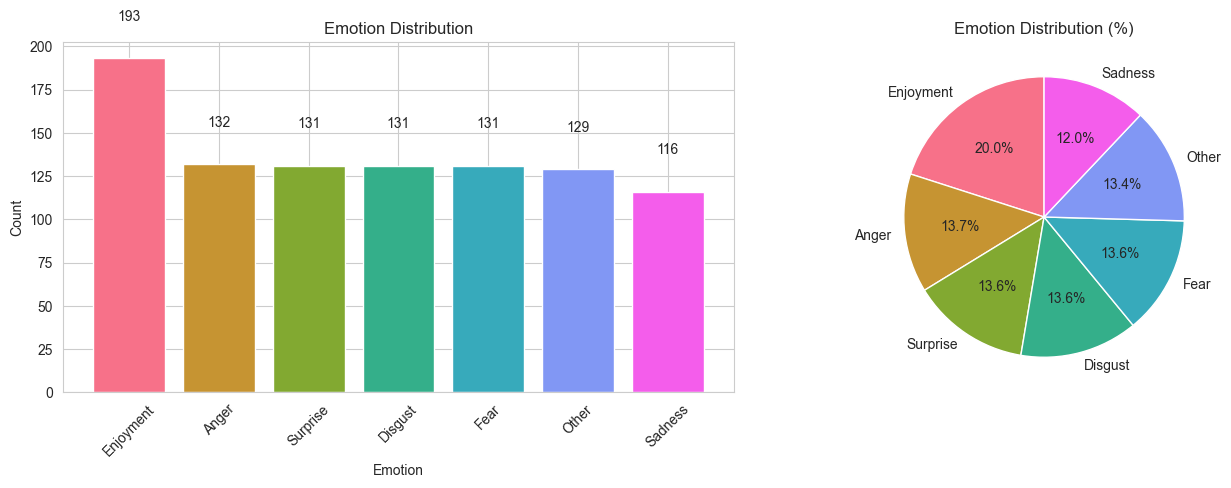

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('husl', len(emotion_counts))

bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].set_title('Emotion Distribution')
axes[0].tick_params(axis='x', rotation=45)
for bar, cnt in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(cnt), ha='center', va='bottom', fontsize=10)

axes[1].pie(emotion_counts.values, labels=emotion_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Emotion Distribution (%)')

plt.tight_layout()
plt.show()

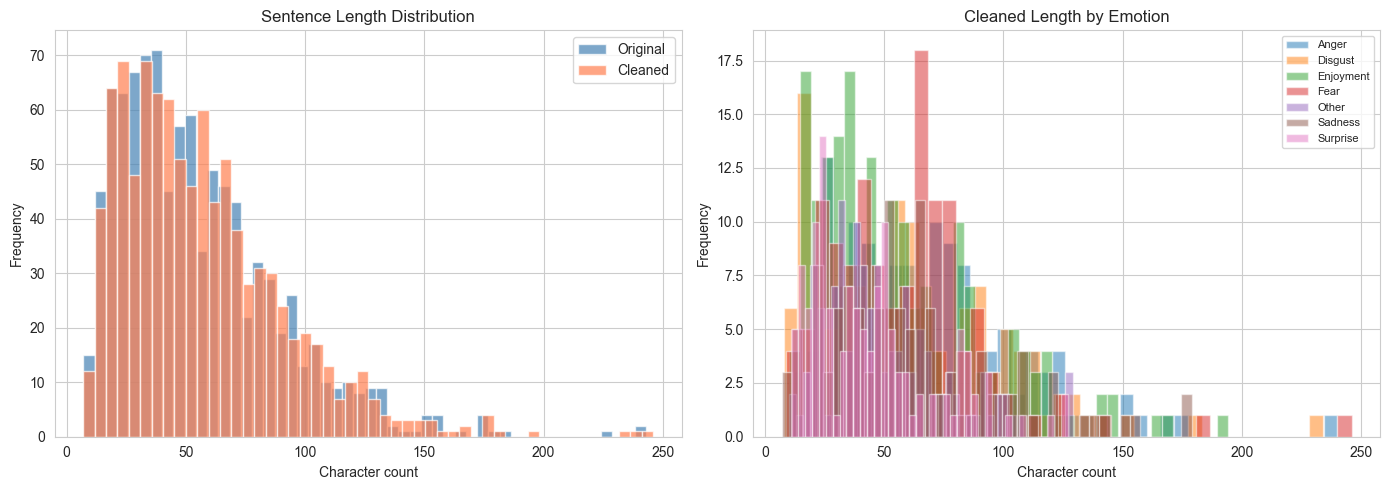

Original  – mean: 55.2, max: 243
Cleaned   – mean: 56.9, max: 246
Avg change: +2.9%


In [12]:
df['_orig_len']  = df[TEXT_COL].str.len()
df['_clean_len'] = df[CLEAN_COL].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['_orig_len'],  bins=50, alpha=0.7, label='Original', color='steelblue')
axes[0].hist(df['_clean_len'], bins=50, alpha=0.7, label='Cleaned',  color='coral')
axes[0].set_title('Sentence Length Distribution')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for label in sorted(df[LABEL_COL].unique()):
    subset = df.loc[df[LABEL_COL] == label, '_clean_len']
    axes[1].hist(subset, bins=40, alpha=0.5, label=label)
axes[1].set_title('Cleaned Length by Emotion')
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

mean_orig  = df['_orig_len'].mean()
mean_clean = df['_clean_len'].mean()
pct_change = (mean_clean - mean_orig) / mean_orig * 100

print(f'Original  – mean: {mean_orig:.1f}, max: {df["_orig_len"].max()}')
print(f'Cleaned   – mean: {mean_clean:.1f}, max: {df["_clean_len"].max()}')
print(f'Avg change: {pct_change:+.1f}%')

df.drop(columns=['_orig_len', '_clean_len'], inplace=True)

## 7. Shuffle & Export

In [13]:
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f'Shuffled. Shape: {df.shape}')
df.head()

Shuffled. Shape: (963, 4)


,Sentence,Emotion,emotion_vn,Sentence_clean
0,cay đắng ngọt bùi . nhưng cay đắng thì thường ...,Other,khác,cay đắng ngọt bùi . nhưng cay đắng thì thường ...
1,"quàooo hay vậy sao , chà chà =))))",Surprise,ngạc nhiên,"quào hay vậy sao , chà chà cười lớn"
2,nhìn là biết đỏ chót rồi,Other,khác,nhìn là biết đỏ chót rồi
3,"Mình ghét nhất mấy con chuột, thấy là muốn xỉu...",Fear,sợ hãi,"mình ghét nhất mấy con chuột, thấy là muốn xỉu..."
4,làm ở đâu cũng vậy cũng có đầy rẫy những khó k...,Other,khác,làm ở đâu cũng vậy cũng có đầy rẫy những khó k...


In [14]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_FILE, index=False)
print(f'Saved {len(df)} records → {OUTPUT_FILE}')
print(f'Final columns: {df.columns.tolist()}')

Saved 963 records → /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/ttest_gen_final.csv
Final columns: ['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean']
